<a href="https://colab.research.google.com/github/abhijitbhatt1221-program/Stock_Market_Analysis_Using_LSTM/blob/main/Copy_of_LSTM_Improved_model(diff_dataset).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Import all the required libraries

1.   List item
2.   List item



---



In [7]:
import pandas as pd
import datetime as dt
from datetime import date
import matplotlib.pyplot as plt
import yfinance as yf
import numpy as np
import tensorflow as tf
import matplotlib.dates as mdates


# Define start day to fetch the dataset from the yahoo finance library

---



In [8]:


START = "2010-01-01"
TODAY = date.today().strftime("%Y-%m-%d")

# Define a function to load the dataset

def load_data(ticker):
    data = yf.download(ticker, START, TODAY)
    data.reset_index(inplace=True)
    return data

In [9]:
data = load_data('TCS.NS')
df=data
df.head()

/tmp/ipykernel_6976/1794888428.py:7: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, START, TODAY)
[*********************100%***********************]  1 of 1 completed


Price,Date,Close,High,Low,Open,Volume
Ticker,,TCS.NS,TCS.NS,TCS.NS,TCS.NS,TCS.NS
0,2010-01-04,262.774475,265.309052,261.865511,263.875692,1963682
1,2010-01-05,262.844330,265.536229,260.991471,263.945568,2014488
2,2010-01-06,256.901154,262.966670,256.254408,262.844298,3349176
3,2010-01-07,249.751968,258.491889,248.563331,257.128453,6474892
4,2010-01-08,244.647827,251.185291,243.494162,250.311299,6048178


In [10]:
# Check available columns
print("Columns before dropping:", df.columns)

# List of columns you want to drop
cols_to_drop = ['Date', 'Adj Close']

# Drop only those that exist
existing_cols_to_drop = [col for col in cols_to_drop if col in df.columns]
df = df.drop(existing_cols_to_drop, axis=1)

# Show first few rows
print("Columns after dropping:", df.columns)
print(df.head())


Columns before dropping: MultiIndex([(  'Date',       ''),
            ( 'Close', 'TCS.NS'),
            (  'High', 'TCS.NS'),
            (   'Low', 'TCS.NS'),
            (  'Open', 'TCS.NS'),
            ('Volume', 'TCS.NS')],
           names=['Price', 'Ticker'])
Columns after dropping: MultiIndex([( 'Close', 'TCS.NS'),
            (  'High', 'TCS.NS'),
            (   'Low', 'TCS.NS'),
            (  'Open', 'TCS.NS'),
            ('Volume', 'TCS.NS')],
           names=['Price', 'Ticker'])
Price        Close        High         Low        Open   Volume
Ticker      TCS.NS      TCS.NS      TCS.NS      TCS.NS   TCS.NS
0       262.774475  265.309052  261.865511  263.875692  1963682
1       262.844330  265.536229  260.991471  263.945568  2014488
2       256.901154  262.966670  256.254408  262.844298  3349176
3       249.751968  258.491889  248.563331  257.128453  6474892
4       244.647827  251.185291  243.494162  250.311299  6048178


/tmp/ipykernel_6976/2560777674.py:9: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  df = df.drop(existing_cols_to_drop, axis=1)


Visualizing Closing Price

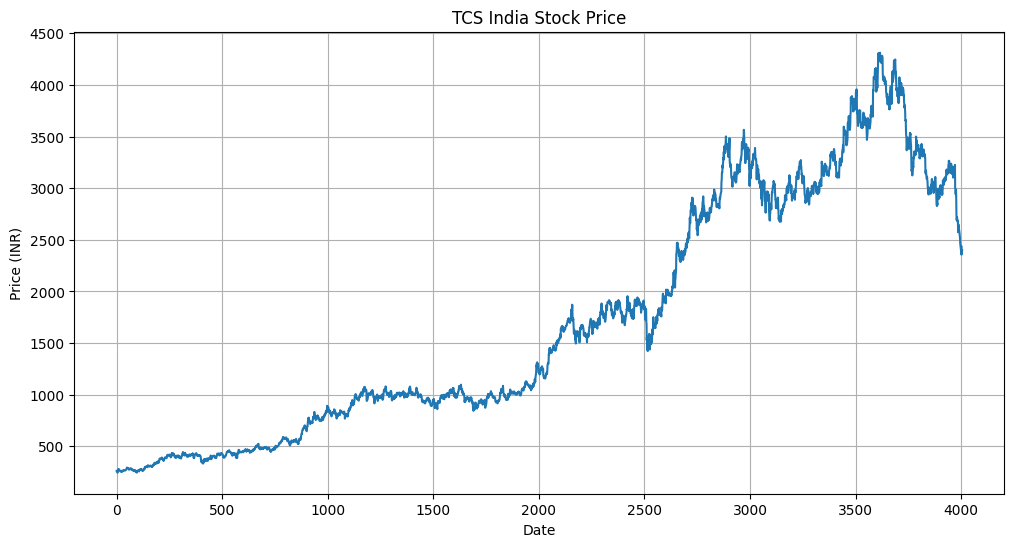

In [11]:
plt.figure(figsize=(12, 6))
plt.plot(df['Close'])
plt.title("TCS India Stock Price")
plt.xlabel("Date")
plt.ylabel("Price (INR)")
plt.grid(True)
plt.show()

In [12]:
df

Price,Close,High,Low,Open,Volume
Ticker,TCS.NS,TCS.NS,TCS.NS,TCS.NS,TCS.NS
0,262.774475,265.309052,261.865511,263.875692,1963682
1,262.844330,265.536229,260.991471,263.945568,2014488
2,256.901154,262.966670,256.254408,262.844298,3349176
3,249.751968,258.491889,248.563331,257.128453,6474892
4,244.647827,251.185291,243.494162,250.311299,6048178
...,...,...,...,...,...
4001,2440.800049,2482.899902,2410.000000,2410.000000,3082388
4002,2356.000000,2424.000000,2350.199951,2417.000000,2757060
4003,2390.600098,2407.800049,2364.199951,2386.000000,4206320


# Plotting moving averages of 100 day

---



In [13]:
ma100 = df.Close.rolling(100).mean()
ma100

Ticker,TCS.NS
0,NaN
1,NaN
2,NaN
3,NaN
4,NaN
...,...
4001,2982.295442
4002,2975.770356
4003,2969.378147
4004,2963.183115


Text(0.5, 1.0, 'Graph Of Moving Averages Of 100 Days')

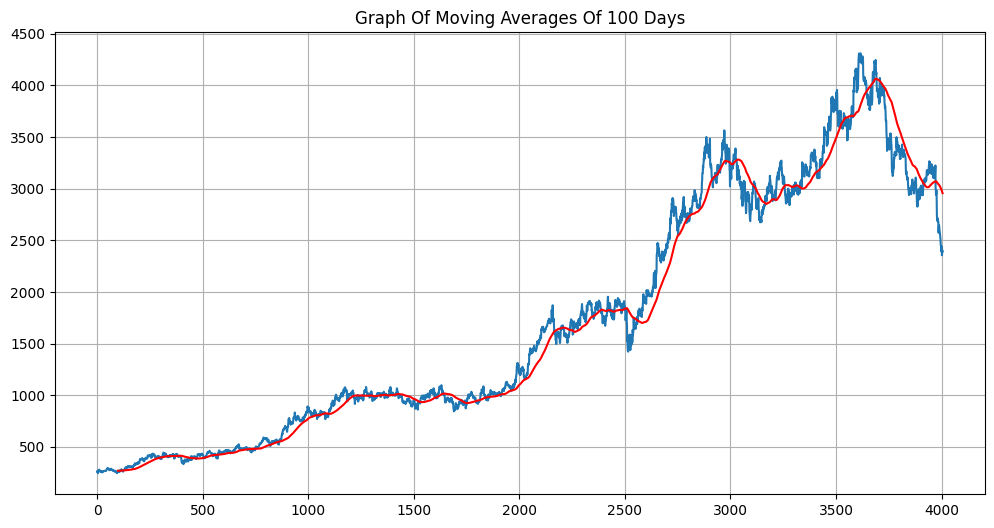

In [14]:
plt.figure(figsize = (12,6))
plt.plot(df.Close)
plt.plot(ma100, 'r')
plt.grid(True)
plt.title('Graph Of Moving Averages Of 100 Days')

# Defining 200 days moving averages and plotting comparision graph with 100 days moving averages

---



In [15]:
ma200 = df.Close.rolling(200).mean()
ma200

Ticker,TCS.NS
0,NaN
1,NaN
2,NaN
3,NaN
4,NaN
...,...
4001,3041.578175
4002,3036.685374
4003,3032.181124
4004,3027.615082


Text(0.5, 1.0, 'Comparision Of 100 Days And 200 Days Moving Averages')

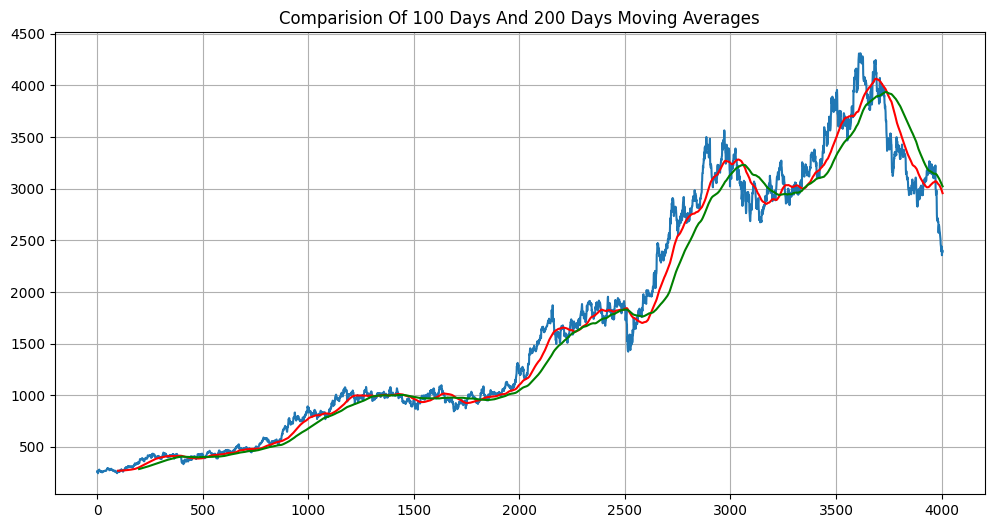

In [16]:
plt.figure(figsize = (12,6))
plt.plot(df.Close)
plt.plot(ma100, 'r')
plt.plot(ma200, 'g')
plt.grid(True)
plt.title('Comparision Of 100 Days And 200 Days Moving Averages')

In [17]:
df.shape

(4006, 5)

# Spliting the dataset into training (70%) and testing (30%) set

In [18]:
# Splitting data into training and testing

train = pd.DataFrame(data[0:int(len(data)*0.70)])
test = pd.DataFrame(data[int(len(data)*0.70): int(len(data))])

print(train.shape)
print(test.shape)

(2804, 6)
(1202, 6)


In [19]:
train.head()

Price,Date,Close,High,Low,Open,Volume
Ticker,,TCS.NS,TCS.NS,TCS.NS,TCS.NS,TCS.NS
0,2010-01-04,262.774475,265.309052,261.865511,263.875692,1963682
1,2010-01-05,262.844330,265.536229,260.991471,263.945568,2014488
2,2010-01-06,256.901154,262.966670,256.254408,262.844298,3349176
3,2010-01-07,249.751968,258.491889,248.563331,257.128453,6474892
4,2010-01-08,244.647827,251.185291,243.494162,250.311299,6048178


In [20]:
test.head()

Price,Date,Close,High,Low,Open,Volume
Ticker,,TCS.NS,TCS.NS,TCS.NS,TCS.NS,TCS.NS
2804,2021-05-19,2709.315430,2740.962203,2696.217268,2711.073584,1986041
2805,2021-05-20,2689.975586,2715.293046,2683.030964,2696.217118,2329027
2806,2021-05-21,2707.997314,2714.766166,2685.668839,2690.855309,1685566
2807,2021-05-24,2708.875732,2729.534042,2700.524501,2708.875732,1652260
2808,2021-05-25,2750.835938,2763.424060,2722.656298,2731.401644,1841613


# Using MinMax scaler for normalization of the dataset

---



In [21]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler(feature_range=(0,1))

In [22]:
train_close = train.iloc[:, 4:5].values
test_close = test.iloc[:, 4:5].values

In [23]:
data_training_array = scaler.fit_transform(train_close)
data_training_array

array([[0.00657204],
       [0.0065979 ],
       [0.00619037],
       ...,
       [0.91688436],
       [0.90273348],
       [0.9173723 ]])

In [24]:
x_train = []
y_train = []

for i in range(100, data_training_array.shape[0]):
    x_train.append(data_training_array[i-100: i])
    y_train.append(data_training_array[i, 0])

x_train, y_train = np.array(x_train), np.array(y_train)

In [25]:
x_train.shape

(2704, 100, 1)

# ML Model (LSTM)

---



In [26]:
from tensorflow.keras.layers import Dense, Dropout, LSTM
from tensorflow.keras.models import Sequential

In [27]:
model = Sequential()
model.add(LSTM(units = 50, activation = 'relu', return_sequences=True
              ,input_shape = (x_train.shape[1], 1)))
model.add(Dropout(0.2))


model.add(LSTM(units = 60, activation = 'relu', return_sequences=True))
model.add(Dropout(0.3))


model.add(LSTM(units = 80, activation = 'relu', return_sequences=True))
model.add(Dropout(0.4))


model.add(LSTM(units = 120, activation = 'relu'))
model.add(Dropout(0.5))

model.add(Dense(units = 1))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [28]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 100, 50)        │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 100, 50)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 100, 60)        │        26,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 100, 60)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 100, 80)        │        45,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 100, 80)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 120)            │        96,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 120)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           121 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 178,761 (698.29 KB)

 Trainable params: 178,761 (698.29 KB)

 Non-trainable params: 0 (0.00 B)

# Training the model

---



In [29]:
import tensorflow as tf
model.compile(optimizer = 'adam', loss = 'mean_squared_error', metrics=[tf.keras.metrics.MeanAbsoluteError()])
model.fit(x_train, y_train,epochs = 100)

Epoch 1/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 19s 102ms/step - loss: 0.0216 - mean_absolute_error: 0.0971
Epoch 2/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - loss: 0.0045 - mean_absolute_error: 0.0449
Epoch 3/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - loss: 0.0046 - mean_absolute_error: 0.0451
Epoch 4/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - loss: 0.0040 - mean_absolute_error: 0.0416
Epoch 5/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 5s 35ms/step - loss: 0.0034 - mean_absolute_error: 0.0390
Epoch 6/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - loss: 0.0031 - mean_absolute_error: 0.0366
Epoch 7/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 3s 40ms/step - loss: 0.0034 - mean_absolute_error: 0.0377
Epoch 8/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - loss: 0.0028 - mean_absolute_error: 0.0342
Epoch 9/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 5s 35ms/step - loss: 0.0028 - mean_absolute_error: 0.0344
Epoch 10/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - loss: 0.0026 - mean_absolute_error: 0.0336
Epoch 11/100
85/85 ━━━━━━━━

In [30]:
model.save('keras_model.h5')

In [31]:
test_close.shape

(1202, 1)

In [32]:
past_100_days = pd.DataFrame(train_close[-100:])

In [33]:
test_df = pd.DataFrame(test_close)

**Defining the final dataset for testing by including last 100 coloums of the training dataset to get the prediction from the 1st column of the testing dataset.**

---


In [34]:
# final_df = past_100_days.append(test_df, ignore_index = True)
final_df = pd.concat([past_100_days, test_df], ignore_index=True)

In [35]:
final_df.head()

,0
0,2516.404058
1,2510.262093
2,2486.572357
3,2523.467513
4,2552.377392


In [36]:
input_data = scaler.fit_transform(final_df)
input_data

array([[0.07694654],
       [0.07382507],
       [0.06178548],
       ...,
       [0.01067262],
       [0.        ],
       [0.01987144]])

In [37]:
input_data.shape

(1302, 1)

# Testing the model

---



In [38]:
x_test = []
y_test = []
for i in range(100, input_data.shape[0]):
   x_test.append(input_data[i-100: i])
   y_test.append(input_data[i, 0])

In [39]:
x_test, y_test = np.array(x_test), np.array(y_test)
print(x_test.shape)
print(y_test.shape)

(1202, 100, 1)
(1202,)


# Making prediction and plotting the graph of predicted vs actual values

---



In [40]:
# Making predictions

y_pred = model.predict(x_test)

38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 52ms/step


In [41]:
y_pred.shape

(1202, 1)

In [42]:
y_test

array([0.17588145, 0.1683311 , 0.16560613, ..., 0.01067262, 0.        ,
       0.01987144])

In [43]:
y_pred

array([[0.25709203],
       [0.25762513],
       [0.2577865 ],
       ...,
       [0.16845639],
       [0.15893432],
       [0.1498012 ]], dtype=float32)

In [44]:
scaler.scale_

array([0.00050822])

In [45]:
scale_factor = 1/0.00041967
y_pred = y_pred * scale_factor
y_test = y_test * scale_factor

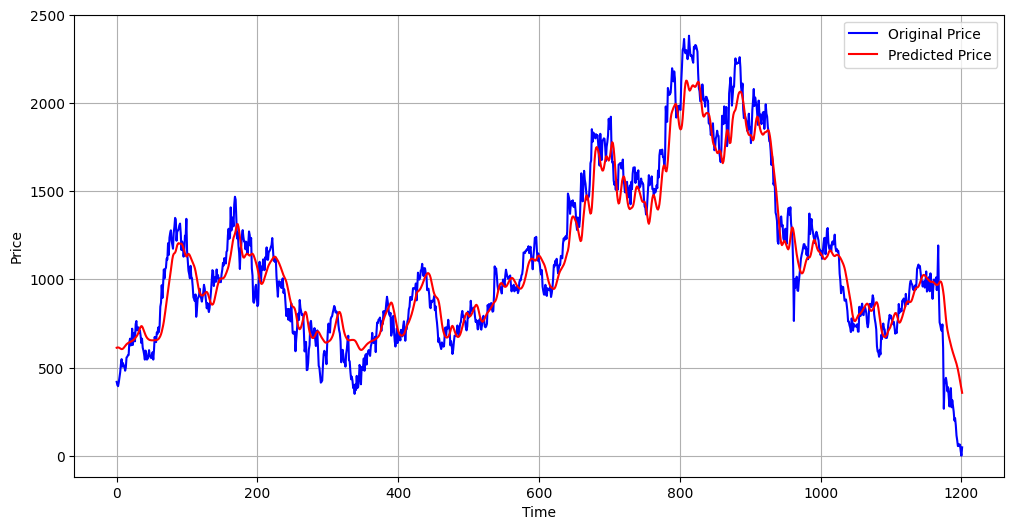

In [46]:
plt.figure(figsize = (12,6))
plt.plot(y_test, 'b', label = "Original Price")
plt.plot(y_pred, 'r', label = "Predicted Price")
plt.xlabel('Time')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.show()

Detected Daily Trend (Drift, based on 500 days): -0.000997
Detected Volatility (stdev, based on 500 days): 0.015372
--------------------------------------------------
*************************************************
  Predicted Price for Tomorrow: INR 2373.82  
*************************************************


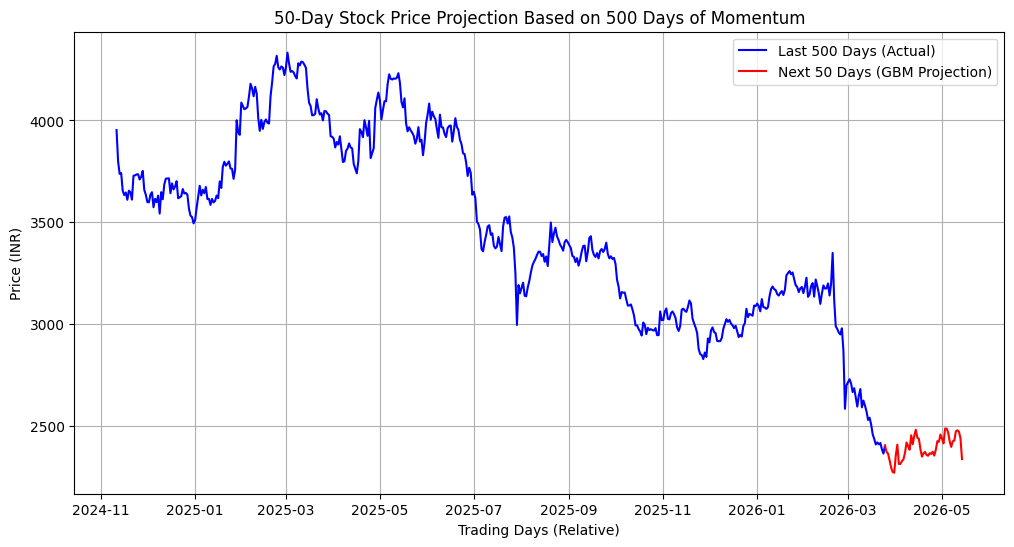

In [47]:
# TREND-BASED PROJECTION (Geometric Brownian Motion - 500 DAYS)
HISTORY_DAYS = 500 # Use the last 500 days for trend calculation
FUTURE_DAYS = 50   # Project 50 days into the future
if len(input_data) < HISTORY_DAYS:
    HISTORY_DAYS = len(input_data)
    print(f"Warning: Only {HISTORY_DAYS} available days used for history.")

last_history_scaled = input_data[-HISTORY_DAYS:]
last_history_prices = scaler.inverse_transform(last_history_scaled).flatten()
log_returns = np.log(last_history_prices[1:] / last_history_prices[:-1])
drift = np.mean(log_returns)
stdev = np.std(log_returns)

print(f"Detected Daily Trend (Drift, based on {HISTORY_DAYS} days): {drift:.6f}")
print(f"Detected Volatility (stdev, based on {HISTORY_DAYS} days): {stdev:.6f}")
print("-" * 50)
future_prices = []
last_price = last_history_prices[-1]

for i in range(FUTURE_DAYS):
    # The GBM formula: Old Price * exp(Trend + Volatility * RandomShock)
    shock = drift + stdev * np.random.normal()
    new_price = last_price * np.exp(shock)
    future_prices.append(new_price)
    last_price = new_price

# Print Predicted Price for Tomorrow
price = future_prices[0]
text = f"Predicted Price for Tomorrow: INR {price:.2f}"
border = "*" * (len(text) + 8)
print(border)
print(f"  {text}  ")
print(border)

plt.figure(figsize=(12, 6))
dates = pd.date_range(end=pd.Timestamp.today(), periods=500)
plt.plot(dates, last_history_prices,
         label=f'Last {HISTORY_DAYS} Days (Actual)', color='blue')

# Plot Prediction
combined_future = np.insert(np.array(future_prices), 0, last_history_prices[-1])
dates = pd.date_range(start=pd.Timestamp.today(), periods=51)
plt.plot(dates, combined_future,
         label=f'Next {FUTURE_DAYS} Days (GBM Projection)', color='red')

plt.title(f'{FUTURE_DAYS}-Day Stock Price Projection Based on {HISTORY_DAYS} Days of Momentum')
plt.xlabel('Trading Days (Relative)')
plt.ylabel('Price (INR)')
plt.legend()
plt.grid(True)
plt.show()

# Model evaluation

Calculation of mean absolute error

In [48]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test, y_pred)
mae_percentage = (mae / np.mean(y_test)) * 100
print("Mean absolute error on test set: {:.2f}%".format(mae_percentage))

Mean absolute error on test set: 9.30%


Calculation of R2 score

In [49]:
from sklearn.metrics import r2_score

# Actual values
actual = y_test

# Predicted values
predicted = y_pred

# Calculate the R2 score
r2 = r2_score(actual, predicted)

print("R2 score:", r2)

R2 score: 0.9209520041717031


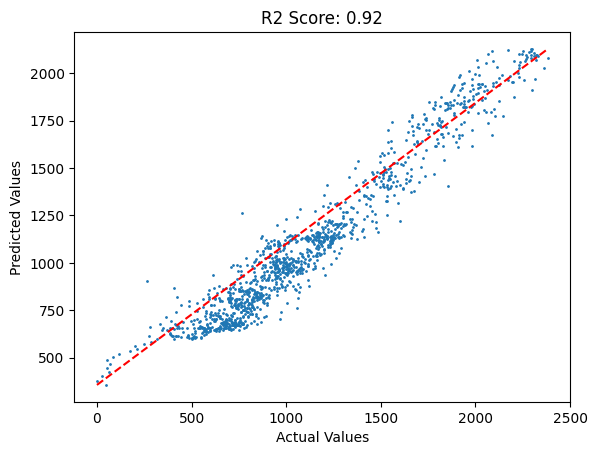

In [50]:
plt.scatter(actual, predicted, s=1)
plt.plot([min(actual), max(actual)], [min(predicted), max(predicted)], 'r--')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title(f'R2 Score: {r2:.2f}')
plt.show()

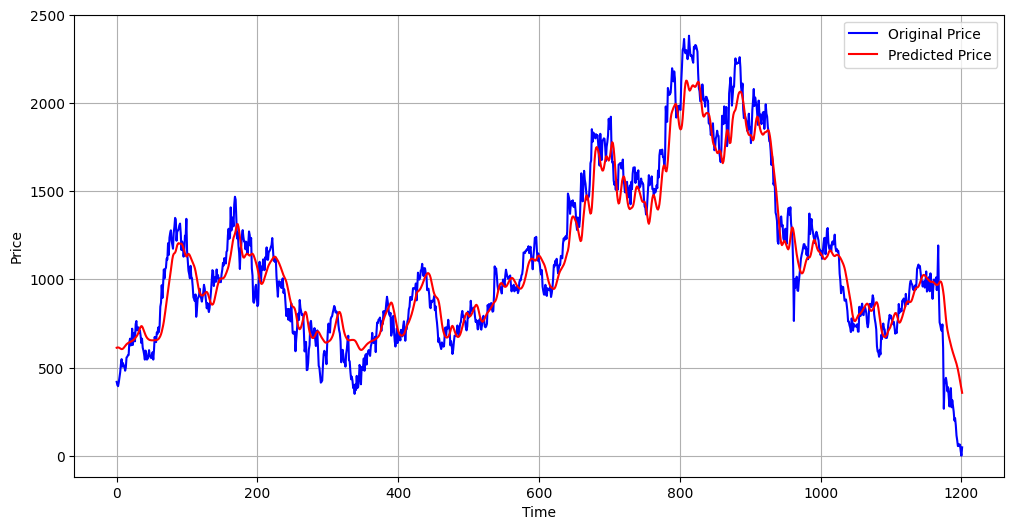

In [51]:
plt.figure(figsize = (12,6))
plt.plot(y_test, 'b', label = "Original Price")
plt.plot(y_pred, 'r', label = "Predicted Price")
plt.xlabel('Time')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.show()

Detected Daily Trend (Drift, based on 500 days): -0.000997
Detected Volatility (stdev, based on 500 days): 0.015372
--------------------------------------------------
*************************************************
  Predicted Price for Tomorrow: INR 2410.27  
*************************************************


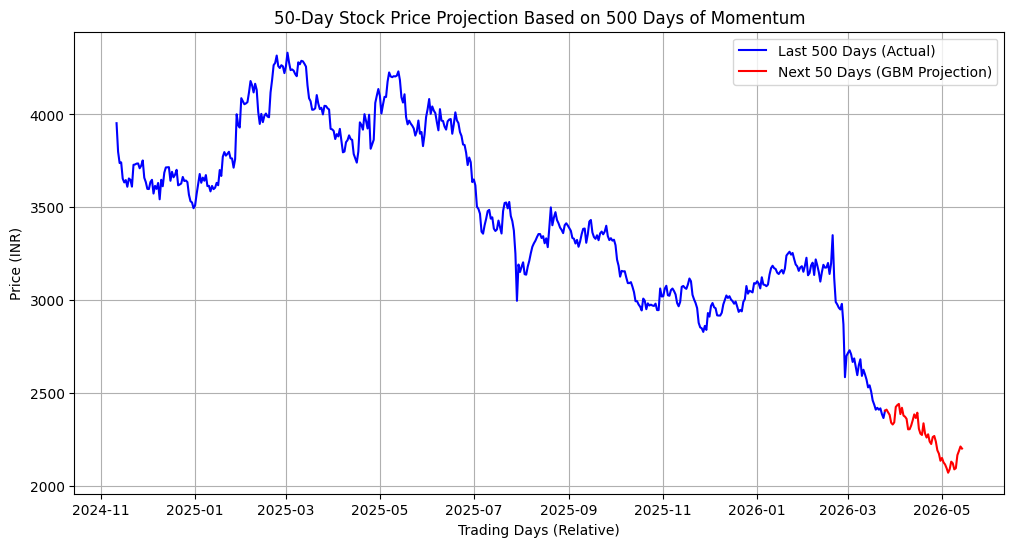

In [52]:
# TREND-BASED PROJECTION (Geometric Brownian Motion - 500 DAYS)
HISTORY_DAYS = 500 # Use the last 500 days for trend calculation
FUTURE_DAYS = 50   # Project 50 days into the future
if len(input_data) < HISTORY_DAYS:
    HISTORY_DAYS = len(input_data)
    print(f"Warning: Only {HISTORY_DAYS} available days used for history.")

last_history_scaled = input_data[-HISTORY_DAYS:]
last_history_prices = scaler.inverse_transform(last_history_scaled).flatten()
log_returns = np.log(last_history_prices[1:] / last_history_prices[:-1])
drift = np.mean(log_returns)
stdev = np.std(log_returns)

print(f"Detected Daily Trend (Drift, based on {HISTORY_DAYS} days): {drift:.6f}")
print(f"Detected Volatility (stdev, based on {HISTORY_DAYS} days): {stdev:.6f}")
print("-" * 50)
future_prices = []
last_price = last_history_prices[-1]

for i in range(FUTURE_DAYS):
    # The GBM formula: Old Price * exp(Trend + Volatility * RandomShock)
    shock = drift + stdev * np.random.normal()
    new_price = last_price * np.exp(shock)
    future_prices.append(new_price)
    last_price = new_price

# Print Predicted Price for Tomorrow
price = future_prices[0]
text = f"Predicted Price for Tomorrow: INR {price:.2f}"
border = "*" * (len(text) + 8)
print(border)
print(f"  {text}  ")
print(border)

plt.figure(figsize=(12, 6))
dates = pd.date_range(end=pd.Timestamp.today(), periods=500)
plt.plot(dates, last_history_prices,
         label=f'Last {HISTORY_DAYS} Days (Actual)', color='blue')

# Plot Prediction
combined_future = np.insert(np.array(future_prices), 0, last_history_prices[-1])
dates = pd.date_range(start=pd.Timestamp.today(), periods=51)
plt.plot(dates, combined_future,
         label=f'Next {FUTURE_DAYS} Days (GBM Projection)', color='red')

plt.title(f'{FUTURE_DAYS}-Day Stock Price Projection Based on {HISTORY_DAYS} Days of Momentum')
plt.xlabel('Trading Days (Relative)')
plt.ylabel('Price (INR)')
plt.legend()
plt.grid(True)
plt.show()

Detected Daily Trend (Drift, based on 500 days): -0.000997
Detected Volatility (stdev, based on 500 days): 0.015372
--------------------------------------------------
*************************************************
  Predicted Price for Tomorrow: INR 2476.84  
*************************************************


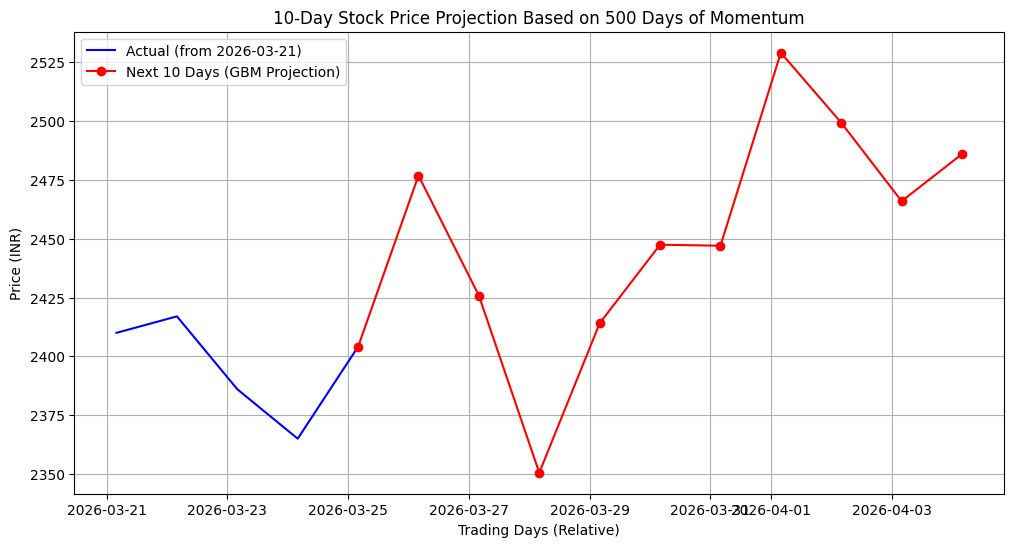

In [53]:
# TREND-BASED PROJECTION (Geometric Brownian Motion - 500 DAYS)
HISTORY_DAYS = 500 # Use the last 500 days for trend calculation
FUTURE_DAYS = 10   # Project 10 days into the future
if len(input_data) < HISTORY_DAYS:
    HISTORY_DAYS = len(input_data)
    print(f"Warning: Only {HISTORY_DAYS} available days used for history.")

last_history_scaled = input_data[-HISTORY_DAYS:]
last_history_prices = scaler.inverse_transform(last_history_scaled).flatten()
log_returns = np.log(last_history_prices[1:] / last_history_prices[:-1])
drift = np.mean(log_returns)
stdev = np.std(log_returns)

print(f"Detected Daily Trend (Drift, based on {HISTORY_DAYS} days): {drift:.6f}")
print(f"Detected Volatility (stdev, based on {HISTORY_DAYS} days): {stdev:.6f}")
print("-" * 50)
future_prices = []
last_price = last_history_prices[-1]

for i in range(FUTURE_DAYS):
    # The GBM formula: Old Price * exp(Trend + Volatility * RandomShock)
    shock = drift + stdev * np.random.normal()
    new_price = last_price * np.exp(shock)
    future_prices.append(new_price)
    last_price = new_price

# Print Predicted Price for Tomorrow
price = future_prices[0]
text = f"Predicted Price for Tomorrow: INR {price:.2f}"
border = "*" * (len(text) + 8)
print(border)
print(f"  {text}  ")
print(border)

plt.figure(figsize=(12, 6))

historical_dates = pd.date_range(end=pd.Timestamp.today(), periods=HISTORY_DAYS)

# Filter out dates before 2026-03-21
filter_start_date = pd.Timestamp('2026-03-21')
filtered_historical_dates = historical_dates[historical_dates >= filter_start_date]
filtered_historical_prices = last_history_prices[historical_dates >= filter_start_date]

# Plot filtered historical data
plt.plot(filtered_historical_dates, filtered_historical_prices,
         label=f'Actual (from {filter_start_date.strftime("%Y-%m-%d")})', color='blue')

# Plot Prediction
combined_future = np.insert(np.array(future_prices), 0, last_history_prices[-1])
future_plot_dates = pd.date_range(start=pd.Timestamp.today(), periods=FUTURE_DAYS + 1)
plt.plot(future_plot_dates, combined_future,
         label=f'Next {FUTURE_DAYS} Days (GBM Projection)', color='red', marker='o', linestyle='-')

plt.title(f'{FUTURE_DAYS}-Day Stock Price Projection Based on {HISTORY_DAYS} Days of Momentum')
plt.xlabel('Trading Days (Relative)')
plt.ylabel('Price (INR)')
plt.legend()
plt.grid(True)
plt.show()

In [54]:
print('Upcoming 10 Days Predicted Prices:')
future_dates = pd.date_range(start=pd.Timestamp.today() + pd.DateOffset(days=1), periods=FUTURE_DAYS)
for i, price in enumerate(future_prices):
    print(f'  {future_dates[i].strftime('%Y-%m-%d')}: INR {price:.2f}')

Upcoming 10 Days Predicted Prices:
  2026-03-26: INR 2476.84
  2026-03-27: INR 2425.81
  2026-03-28: INR 2350.53
  2026-03-29: INR 2414.06
  2026-03-30: INR 2447.45
  2026-03-31: INR 2447.03
  2026-04-01: INR 2529.07
  2026-04-02: INR 2499.31
  2026-04-03: INR 2465.97
  2026-04-04: INR 2485.98


In [55]:
latest_data = data.iloc[-1]
latest_date = latest_data[('Date', '')].strftime('%Y-%m-%d')
latest_close_price = latest_data[('Close', 'TCS.NS')]

print(f"The latest available closing price for TCS.NS on {latest_date} is INR {latest_close_price:.2f}")

The latest available closing price for TCS.NS on 2026-03-24 is INR 2398.80
